# Advanced Cloud Clearing in Sentinel-2: combining spectral and clustering approaches

Our goal here is to prepare a Sentinel-2 image over a region of interest and create a cloud-clearing function that uses both:
- Spectral characteristics of clouds (e.g., high reflectance in blue, low in SWIR)
- A clustering algorithm (e.g., k-means or DBSCAN (but do feel free to use whatever you think is best) on pixel features) to find and expand cloud-masked areas to include neighboring “cloudy-ish” pixels.

My intent is that by the end of this lab you have a function that you can then use in many of your project workflows to ensure that the data you are using is as free of clouds as possible (you will need to re-design it if apply to imagery other than Sentinel 2).

The overview of our workflow is to:
- Load and filter on location, date and overall cloud contamination > Sentinel-2 surface reflectance imagery in Earth Engine.
- Apply the s2cloudless cloud probability algorithm.
- Apply a clustering approach to detect “borderline” cloudy pixels near heavy clouds.
- Generate a clean composite for a chosen date range.

We are using this tutorial from Google as the basis of our work: [Sentinel-2 Cloud Masking with s2cloudless](https://developers.google.com/earth-engine/tutorials/community/sentinel-2-s2cloudless).


**As ever, in this lab whenever we ask you for an visual output, we are expecting you to present it to a publication quality level.**


________________________________________________________________________________
# Implementing S2 Cloudless

In [12]:
# Our usual set up routine
!pip install geemap --quiet

import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import ee
ee.Authenticate()
ee.Initialize(project='geog761-lrei069') # Change this to your own Earth Engine project if required.

OUTPUT_DIR = Path('/content/lab3_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print('Figures will be saved to:', OUTPUT_DIR)

Figures will be saved to: /content/lab3_outputs


First, let us define our area of interest (AOI) and the cloud mask parameters, here is the table from the Earth Engine Catalogue: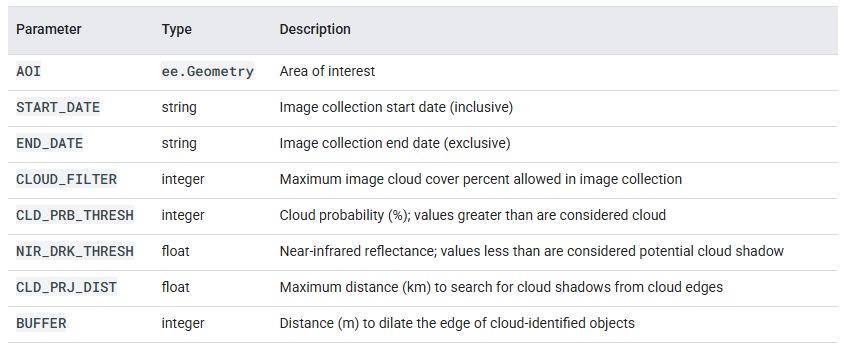

In [13]:
# Control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

Next we use these variables to build a Sentinel 2 image collection. You have done all this before, but now we are using more of the tools at our disposal to get exactly what we want.

Also, from now on we are going to be using functions to make our code more useable and extensible:

In [14]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    # Import and filter S2 SR.
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

    # Import and filter s2cloudless.
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))

    # Join the filtered s2cloudless collection to the SR collection by the 'system:index' property.
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index',
            'rightField': 'system:index'
        })
    }))

In [15]:
# Apply the function in order to generate the collection
s2_sr_cld_col_eval = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [16]:
# As ever, a good idea to do a quick viusalization check
Map = geemap.Map(basemap="HYBRID")
Map.centerObject(AOI, 10)
Map.addLayer(s2_sr_cld_col_eval, {'bands':['B4','B3','B2'], 'min':0, 'max':3000}, 'S2 collection (before)')
Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Yup that is pretty cloudy!

Now, we will define a function to add the s2cloudless probability layer and derived cloud mask as bands to an S2 SR image input.

In [17]:
def add_cloud_bands(img):
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')

    # Condition s2cloudless by the probability threshold value.
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Add the cloud probability layer and cloud mask as image bands.
    return img.addBands(ee.Image([cld_prb, is_cloud]))

The next function we need adds bands that adds layers that identify dark pixels, cloud projection, and identified shadows as bands to an S2 SR image input. Note that the image input needs to be the result of the above add_cloud_bands function because it relies on knowing which pixels are considered cloudy (via the renamed 'CLD_PRB_THRESH' band native to this S2 product).

In [18]:
def add_shadow_bands(img):
    # Identify water pixels from the SCL band.
    not_water = img.select('SCL').neq(6)

    # Identify dark NIR pixels that are not water (potential cloud shadow pixels).
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH*SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')

    # Determine the direction to project cloud shadow from clouds (assumes UTM projection).
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')));

    # Project shadows from clouds for the distance specified by the CLD_PRJ_DIST input.
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST*10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance')
        .mask()
        .rename('cloud_transform'))

    # Identify the intersection of dark pixels with cloud shadow projection.
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')

    # Add dark pixels, cloud projection, and identified shadows as image bands.
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

Finally for this stage, we define a function to assemble all of the cloud and cloud shadow components and produce the final mask.

In [19]:
def add_cld_shdw_mask(img):
    # Add cloud component bands.
    img_cloud = add_cloud_bands(img)

    # Add cloud shadow component bands.
    img_cloud_shadow = add_shadow_bands(img_cloud)

    # Combine cloud and shadow mask, set cloud and shadow as value 1, else 0.
    is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)

    # Remove small cloud-shadow patches and dilate remaining pixels by BUFFER input.
    # 20 m scale is for speed, and assumes clouds don't require 10 m precision.
    is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(BUFFER*2/20)
        .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
        .rename('cloudmask'))

    # Add the final cloud-shadow mask to the image.
    return img_cloud_shadow.addBands(is_cld_shdw)

Let us check this out and see how well it is dealing with our famously cloudy country. To do this we will need a function to pull out the cloud masking component layers, as in the 'final' version we will just apply this layer to remove the clouds rather than hold it as something we will display.

In [20]:
def display_cloud_layers_geemap(col, AOI):
    # Mosaic the image collection.
    img = col.mosaic()

    # Subset layers and prepare them for display.
    clouds = img.select('clouds').selfMask()
    shadows = img.select('shadows').selfMask()
    dark_pixels = img.select('dark_pixels').selfMask()
    probability = img.select('probability')
    cloudmask = img.select('cloudmask').selfMask()
    cloud_transform = img.select('cloud_transform')

    # Create a geemap Map object centered on AOI.
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add layers
    m.addLayer(img, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}, 'S2 image')
    m.addLayer(probability, {'min': 0, 'max': 100}, 'probability (cloud)')
    m.addLayer(clouds, {'palette': ['e056fd']}, 'clouds')
    m.addLayer(cloud_transform, {'min': 0, 'max': 1, 'palette': ['white', 'black']}, 'cloud_transform')
    m.addLayer(dark_pixels, {'palette': ['orange']}, 'dark_pixels')
    m.addLayer(shadows, {'palette': ['yellow']}, 'shadows')
    m.addLayer(cloudmask, {'palette': ['orange']}, 'cloudmask')

    return m

The cell you are about to run, is going to open with a whole lot of layers! Use the layer menu top right of the map to turn them all off except the Sentinel 2 image that we are trying to find the cloud in. Then, one by one add in each layer (which is each a part of the cloud clearing algorithim), and look at what 'part' of the cloud problem it is dealing with. Examine how well it is performing and think about what characteristics it is making the decision to label a given pixel as the given target on.

In [21]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
display_map = display_cloud_layers_geemap(s2_sr_cld_col_eval_disp, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Well now! That is considerably better than what we have been using before!

(1) Zoom in to a cloudy region and look at the S2 image, 'clouds' layer, 'dark pixels',  and the 'shadows' layers. Write a short paragraph that discusses:
- The performance of each masking element. Are they perfect or getting confused? What is causing the confusion?
- How do the three elements work together to define pixels that are not clear?
I am looking for you to show an understanding of both the algorithim you have just applied and the underlying spectral sensing principles.

(10 pts)

### Answer to Question 1
The cloud layer identifies pixels with a s2cloudless probability above the selected threshold. It detects the main cloud areas well, but thin cloud and cloud edges can have lower probabilities and may be missed. Bright surfaces can also have relatively high cloud probabilities because they reflect strongly in the visible bands. The dark pixels layer identifies low reflectance in B8 after water has been excluded using the SCL band. This is useful for finding cloud shadow because shadowed surfaces receive less direct sunlight, but dark forest and shaded urban areas can also be detected. The shadows layer reduces this confusion by only keeping dark pixels that occur in the direction that a shadow is expected to fall from a detected cloud using the solar azimuth. The final mask combines the detected cloud and shadow pixels and then applies a buffer around them. The three elements therefore use cloud probability, near infrared reflectance and solar geometry together to identify pixels that are not clear.

(2) Exercise: change the above CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, and BUFFER input variables and rerun the previous cells to see how the results change. Present a figure that compares between the first version you ran and your final version. State the values you have selected and describe the improvements in performance you have managed to achieve in the figure caption.

(10 pts)

### Answer to Question 2
The final values selected were CLD_PRB_THRESH = 40, NIR_DRK_THRESH = 0.20, CLD_PRJ_DIST = 2 km and BUFFER = 75 m. The lower cloud probability threshold detects more thin cloud and cloud edge pixels. The higher NIR dark threshold includes moderately dark shadow pixels, while the longer projection distance allows shadows further from the detected cloud to be included. The 75 m buffer expands the mask around cloud boundaries without masking as much surrounding clear land as a larger buffer.

Finally for this section, let's apply this cloud mask to our data and generate a 'cloud free' image. Replace my parameters used below with the ones you have selected based on your answer to question 2.

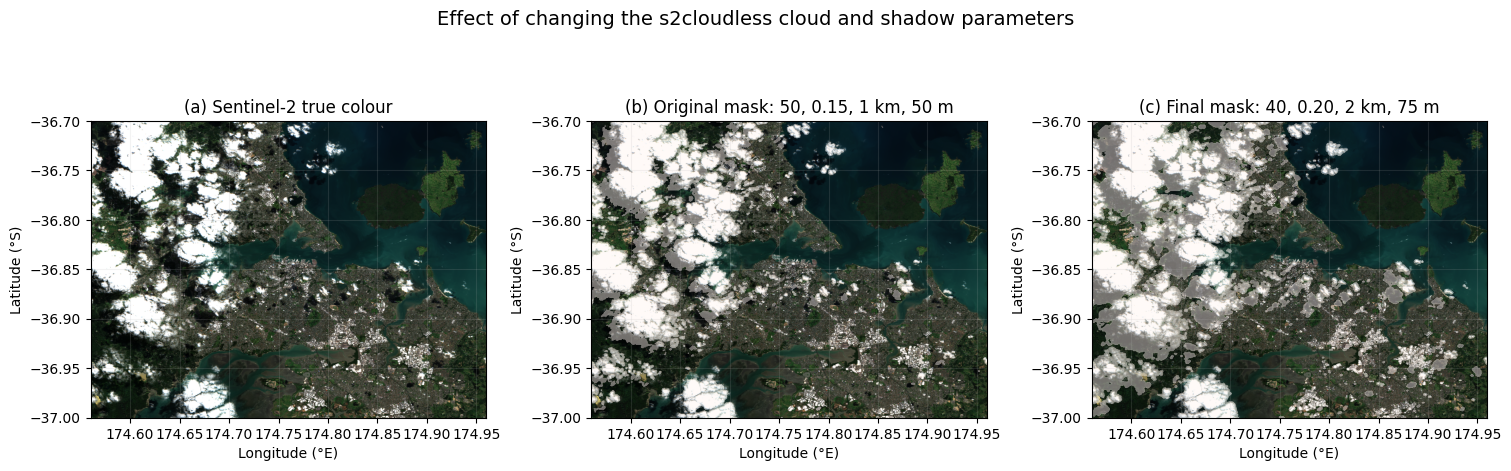

Original mask covers 25.9% of displayed pixels.
Final mask covers 36.6% of displayed pixels.
Pixels newly included by the tuned mask: 10.7% of displayed pixels.
Saved: /content/lab3_outputs/Lab3_Q2_parameter_comparison.png


In [22]:
# Question 2: compare the original settings with the final tuned settings.

def build_mask_mosaic(cld_prob, nir_dark, projection_km, buffer_m):
    global CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, BUFFER

    CLD_PRB_THRESH = cld_prob
    NIR_DRK_THRESH = nir_dark
    CLD_PRJ_DIST = projection_km
    BUFFER = buffer_m

    col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)
    return col.map(add_cld_shdw_mask).mosaic()

ORIGINAL_PARAMS = {
    'cld_prob': 50,
    'nir_dark': 0.15,
    'projection_km': 1,
    'buffer_m': 50
}

FINAL_PARAMS = {
    'cld_prob': 40,
    'nir_dark': 0.20,
    'projection_km': 2,
    'buffer_m': 75
}

original_img = build_mask_mosaic(**ORIGINAL_PARAMS)
final_img = build_mask_mosaic(**FINAL_PARAMS)

# Keep the selected final values for the following cloud-free composite.
CLD_PRB_THRESH = FINAL_PARAMS['cld_prob']
NIR_DRK_THRESH = FINAL_PARAMS['nir_dark']
CLD_PRJ_DIST = FINAL_PARAMS['projection_km']
BUFFER = FINAL_PARAMS['buffer_m']

# Use the same Auckland region for both versions so the comparison is direct.
q2_region = ee.Geometry.Rectangle([174.56, -37.00, 174.96, -36.70])

q2_stack = ee.Image.cat([
    original_img.select(['B4', 'B3', 'B2']).rename(['R', 'G', 'B']),
    original_img.select('cloudmask').rename('mask_original'),
    final_img.select('cloudmask').rename('mask_final')
])

q2_arr = geemap.ee_to_numpy(q2_stack, region=q2_region, scale=60)

q2_rgb = np.clip(q2_arr[..., :3] / 3000.0, 0, 1)
q2_original = q2_arr[..., 3] > 0.5
q2_final = q2_arr[..., 4] > 0.5
q2_added = q2_final & ~q2_original
q2_removed = q2_original & ~q2_final

extent_q2 = [174.56, 174.96, -37.00, -36.70]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

axes[0].imshow(q2_rgb, extent=extent_q2, origin='upper')
axes[0].set_title('(a) Sentinel-2 true colour')

axes[1].imshow(q2_rgb, extent=extent_q2, origin='upper')
axes[1].imshow(
    np.ma.masked_where(~q2_original, q2_original),
    extent=extent_q2, origin='upper', alpha=0.45, cmap='Reds'
)
axes[1].set_title('(b) Original mask: 50, 0.15, 1 km, 50 m')

axes[2].imshow(q2_rgb, extent=extent_q2, origin='upper')
axes[2].imshow(
    np.ma.masked_where(~q2_final, q2_final),
    extent=extent_q2, origin='upper', alpha=0.45, cmap='Reds'
)
axes[2].set_title('(c) Final mask: 40, 0.20, 2 km, 75 m')

for ax in axes:
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°S)')
    ax.grid(alpha=0.15)

fig.suptitle('Effect of changing the s2cloudless cloud and shadow parameters', fontsize=14)

q2_path = OUTPUT_DIR / 'Lab3_Q2_parameter_comparison.png'
fig.savefig(q2_path, dpi=300, bbox_inches='tight')
plt.show()

q2_original_fraction = float(q2_original.mean() * 100)
q2_final_fraction = float(q2_final.mean() * 100)
q2_added_fraction = float(q2_added.mean() * 100)

print(f'Original mask covers {q2_original_fraction:.1f}% of displayed pixels.')
print(f'Final mask covers {q2_final_fraction:.1f}% of displayed pixels.')
print(f'Pixels newly included by the tuned mask: {q2_added_fraction:.1f}% of displayed pixels.')
print('Saved:', q2_path)

In [23]:
# Final control variables selected for Question 2
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 40
NIR_DRK_THRESH = 0.20
CLD_PRJ_DIST = 2
BUFFER = 75

# Rebuild the collection using the final values.
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [24]:
# Define a function to apply the cloud mask to the S2 spectral bands
def apply_cld_shdw_mask(img):
    cloudmask = img.select('cloudmask')
    # Mask cloudy pixels
    masked_img = img.updateMask(cloudmask.Not())
    # Keep cloudmask and probability bands
    cloudmask_band = img.select('cloudmask')
    probability_band = img.select('probability')
    masked_img = masked_img.addBands([cloudmask_band, probability_band], overwrite=True)
    return masked_img

In [25]:
# Process the collection
s2_sr_median = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .median())

In [26]:
# Display the cloud free composite
def display_cloud_free_mosaic(s2_sr_median, AOI):
    # Create a geemap Map object and center it on the AOI
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add the Sentinel-2 RGB mosaic
    m.addLayer(
        s2_sr_median,
        {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1},
        'S2 cloud-free mosaic')

    return m

display_map = display_cloud_free_mosaic(s2_sr_median, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Now THAT is a cloud-free image! (Well, with my thresholds we still have a little there over the SW forest, can yours do better?).

(3) This process has managed to avoid masking out the many bright white roofs of Auckland as cloud, despite them appearing very similar to cloud in the RGB visualization. How has the algorithm achieved this?
(5 pts)


________________________________________________________________________________

### Answer to Question 3
The algorithm does not classify cloud from the RGB image alone. The RGB display only uses B4, B3 and B2, so bright white roofs and clouds can appear similar to the eye. s2cloudless instead calculates cloud probability using Sentinel-2 multispectral information, including bands outside the visible wavelengths. White roofs have a different spectral response from cloud across the near infrared and short-wave infrared bands, even when they look similar in true colour. This allows the cloud probability model to separate most bright roofs from actual cloud before the final cloud and shadow mask is produced.

# Extending S2 Cloudless with a clustering approach
The process we explored in the prior section has worked really rather well! But you saw in the exercise that it does rely on you setting the local paramaters. This is a manual process and one that is at risk of reduced effectiveness if we are clearing cloud over a wide area. This is particularly the case for cirrus and other thin clouds (e.g. cloud edges) that the thresholds are very sensitive to.

Therefore, let us extend our cloud-clearing algorithim into one that includes a clustering-step in which we sample the pixels around the edge of our clouds and test if they should be clustered into our cloud mask.

We will now implement the following workflow:
1.   Reset our data stack, with somewhat worse settings than the very good ones we have just set, in order to make this a better (for humans) teaching exercise.
2.   Define what counts as inside a cloud, outside a cloud and the edge of a cloud.
3.   Vizualize these samples and determine if we can perform meaningful clustering on them.
4.   Perform clustering of the border zone pixels with either the clouds or the cloud free.





In [27]:
# First, make cloud clearing deliberately less conservative to demonstrate clustering.
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 30
CLD_PRB_THRESH = 30
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 5

# Re-collect the S2 as we have changed our filtering params.
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

# Keep the original reflectance under cloudy pixels. If apply_cld_shdw_mask() were used here,
# the B-band values at cloud pixels would be masked before we try to learn their spectral
# signature. We therefore add the cloud/shadow bands but do not remove cloud pixels.
s2_sr_mosaic = s2_sr_cld_col.map(add_cld_shdw_mask).mosaic()

In [28]:
def define_cloud_zones(img, edge_buffer=120):
    cloudmask = img.select('cloudmask')

    # Interior cloud pixels: cloudmask==1, away from edges (small erosion)
    cloud_interior = cloudmask.selfMask().focal_min(3)

    # Interior clear pixels: cloudmask==0, away from edges (medium erosion)
    clear_interior = cloudmask.Not().selfMask().focal_min(10)

    # Cloud edge pixels: buffer zone around clouds, but outside cloudmask
    cloud_edge = cloudmask.focal_max(edge_buffer / 10).And(cloudmask.Not())

    return cloud_interior, clear_interior, cloud_edge


In [29]:
def sample_zones(img, AOI, edge_buffer=20):
    cloudmask = img.select('cloudmask')

    cloud_interior = cloudmask.selfMask()
    clear_interior = cloudmask.Not().selfMask()
    cloud_edge = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B9', 'B8', 'B11', 'B12']
    if 'probability' in img.bandNames().getInfo():
        sample_bands.append('probability')

    img_for_sampling = img.select(sample_bands)

    cloud_samples = img_for_sampling.updateMask(cloud_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=0, geometries=True)

    clear_samples = img_for_sampling.updateMask(clear_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=1, geometries=True)

    edge_samples = img_for_sampling.updateMask(cloud_edge).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=2, geometries=True)

    return cloud_samples, clear_samples, edge_samples


In [30]:
# Gather our samples
cloud_samples, clear_samples, edge_samples = sample_zones(s2_sr_mosaic, AOI)

# Function to convert a earth engine feature class to a pandas df
def fc_to_df(fc):
    features = fc.getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)
    return pd.DataFrame(rows)


# Carry out the conversion and sanity print out what we have
cloud_df = fc_to_df(cloud_samples)
clear_df = fc_to_df(clear_samples)
edge_df = fc_to_df(edge_samples)

print(f"Cloud samples: {len(cloud_df)}")
print(f"Clear samples: {len(clear_df)}")
print(f"Edge samples: {len(edge_df)}")
print("Cloud columns:", cloud_df.columns)


Cloud samples: 727
Clear samples: 4310
Edge samples: 1930
Cloud columns: Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'B9', 'probability',
       'longitude', 'latitude'],
      dtype='object')


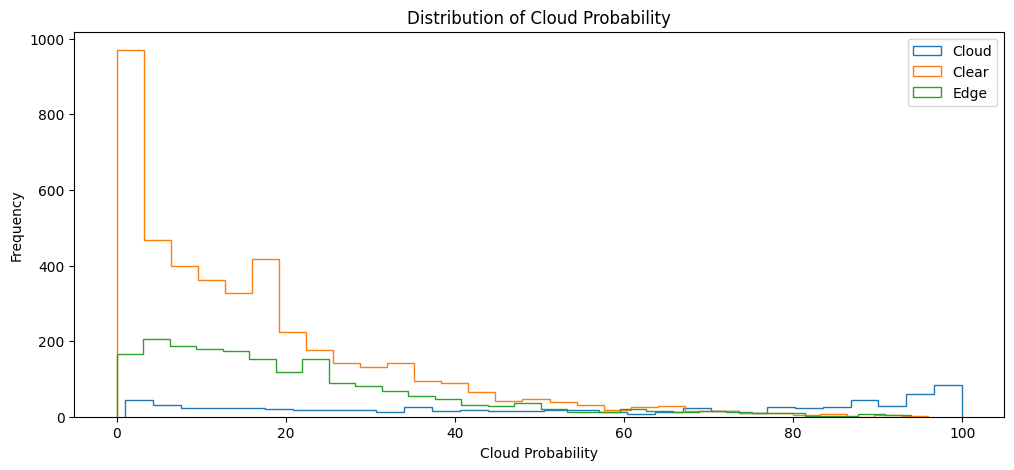

In [31]:
# Histogram of cloud probability by class
plt.figure(figsize=(12, 5))
plt.hist(cloud_df['probability'], bins=30, histtype='step', label='Cloud')
plt.hist(clear_df['probability'], bins=30, histtype='step', label='Clear')
plt.hist(edge_df['probability'], bins=30, histtype='step', label='Edge')
plt.xlabel('Cloud Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Cloud Probability')
plt.show()

Look at the histogram above. What is it telling you about the quality of the training classes you have just created? Think back to Lab 1, and the lecture 2/3 exercises.

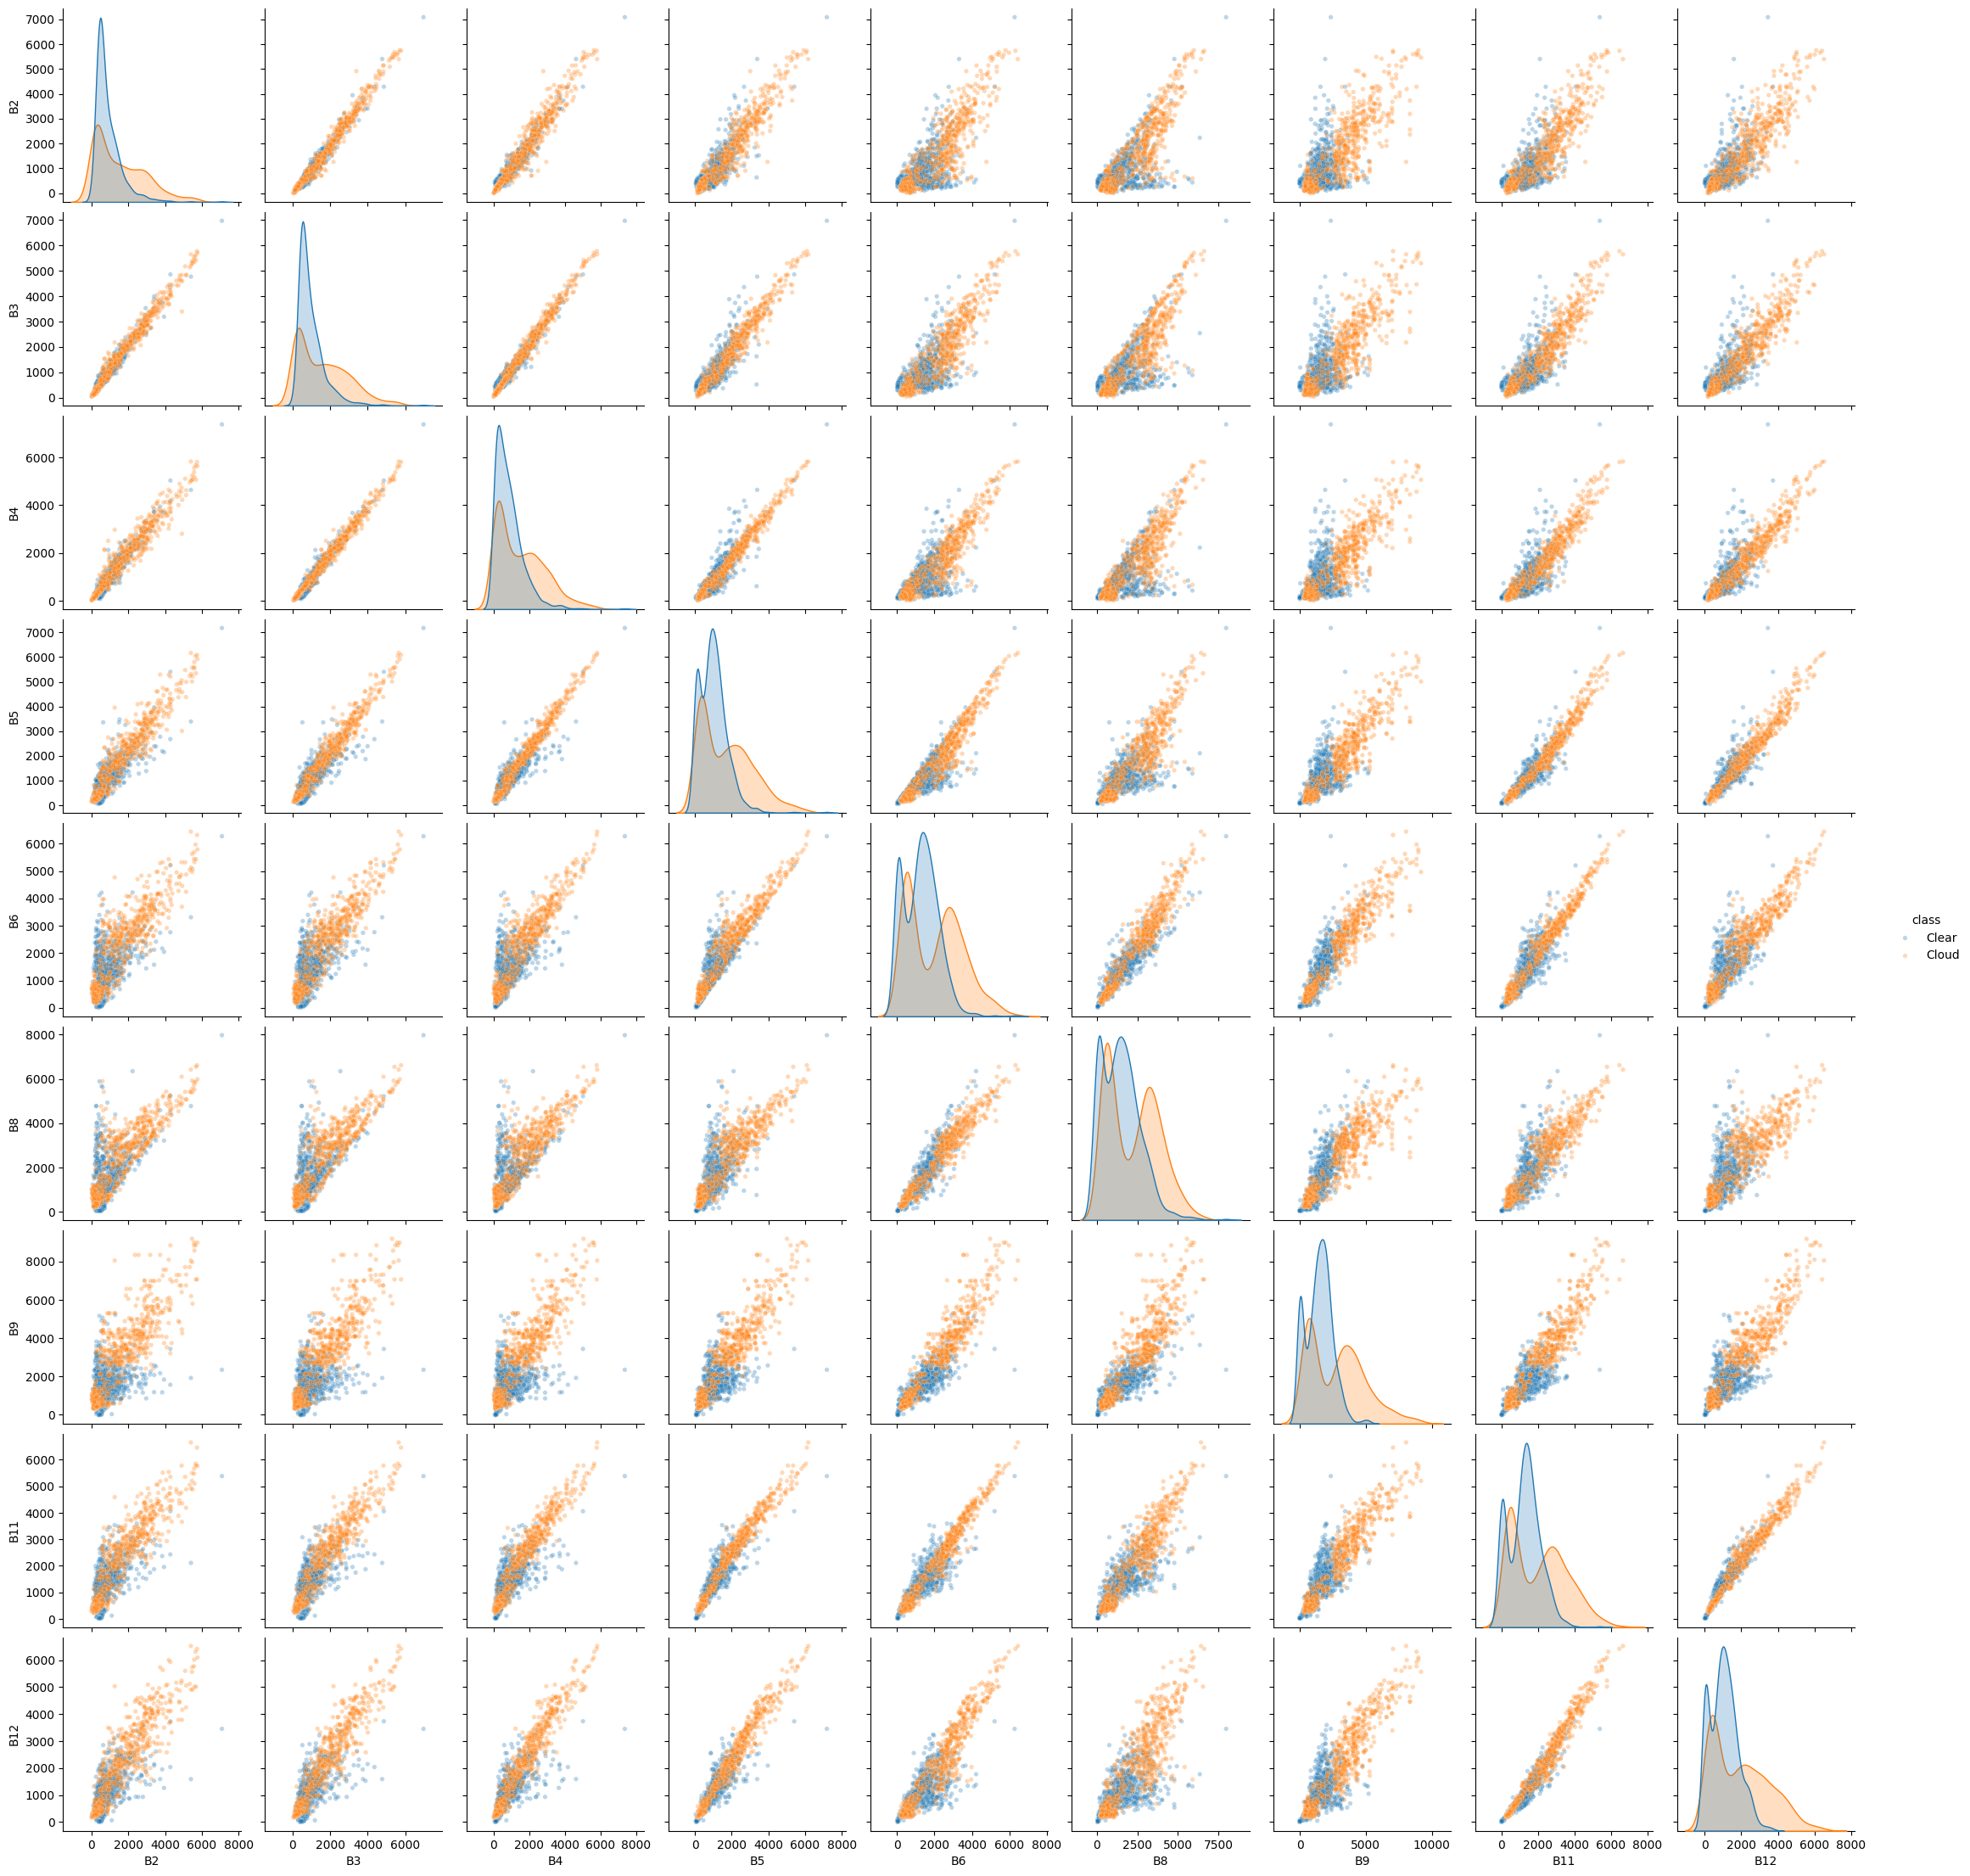

In [32]:
# Plot out all the bands, by the two 'labelled' classes that we want to discriminate between
# Add class labels
cloud_df['class'] = 'Cloud'
clear_df['class'] = 'Clear'

# Combine to one df
combined_df = pd.concat([cloud_df, clear_df])

# We will carry out somne class balancing here
# Find smallest class count
min_count = combined_df['class'].value_counts().min()

# Downsample each class to min_count
balanced_df = combined_df.groupby('class').sample(n=min_count, random_state=42)

# Now plot with balanced_df
# This is going to make a big plot that you will have to scroll around! Pay particular attention to the histogram plots on the diagonal.
bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B8', 'B9', 'B11', 'B12']
sns.pairplot(balanced_df, vars=bands, hue='class', plot_kws={'alpha':0.3, 's':15}, height=2.5)


(4) What do the histograms of cloud detection probability (as judged by s2cloudless) plotted in the three classes we have set here, AND the pair plot of all bands available tell us about our ability to tell cloudy vs non-cloud pixels apart? Make sure to explain your answer with reference to physical principles and the statistical foundations of ML (5 pts)

(5) Which bands are therefore going to be the best to use in our K-means clustering approach and why? (5 pts)

With our choices made, let us now test if we can implement k-means as a tool by which to assign those edge pixels into either the cloudy or clear classes. Noting that I have placed default band choices in the 'features to use for clustering' line. You do not need to use just three bands.

Run this section first with the default bands, and then change it to the ones you have selected in question 5. Observe the difference it makes...

### Answer to Question 4
The histograms show that cloud pixels generally have high s2cloudless probabilities and clear pixels generally have low probabilities. The cloud edge class has a much wider distribution and overlaps both groups. This occurs because edge pixels can contain a mixture of cloud and the surface below, while thin cloud can still allow some surface reflectance to reach the sensor. The pair plot shows a similar pattern across the Sentinel-2 bands. Cloud and clear pixels have different spectral patterns, but there is overlap in individual bands because clear land-cover types such as water, vegetation and built surfaces have very different reflectance values. This means that one band or one cloud probability threshold cannot perfectly separate the classes. Combining several bands provides more information for distinguishing cloud from clear pixels.

### Answer to Question 5
B2, B8, B11 and B12 are the most useful bands for the K-means clustering. B2 captures the high visible reflectance of cloud, while B8 helps separate cloud from vegetation because healthy vegetation has high near infrared reflectance. B11 and B12 add short-wave infrared information, which helps distinguish cloud from bright built surfaces and other land-cover types that can look similar in visible imagery. Using bands from different parts of the spectrum therefore provides better separation than using only the visible bands.

In [33]:
# Use the balanced cloud and clear samples from above.
train_df = balanced_df[
    balanced_df['class'].isin(['Cloud', 'Clear'])
].copy()

# Bands selected from the pair plot and their spectral behaviour.
features = ['B2', 'B8', 'B11', 'B12']

# Remove rows with missing values once so X and y remain aligned.
train_valid = (
    train_df
    .dropna(subset=features)
    .reset_index(drop=True)
)

X_train = train_valid[features].values
y_train = (train_valid['class'] == 'Cloud').astype(int).values

print('Training samples:', len(train_valid))
print(train_valid['class'].value_counts())

# Fit K-means using the selected Sentinel-2 bands.
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)
kmeans.fit(X_train)

# Determine which cluster contains the greatest proportion of known cloud pixels.
cluster_cloud_fraction = {}

for cluster in [0, 1]:
    in_cluster = kmeans.labels_ == cluster

    if in_cluster.sum() > 0:
        cluster_cloud_fraction[cluster] = y_train[in_cluster].mean()
    else:
        cluster_cloud_fraction[cluster] = 0

cloud_cluster = max(
    cluster_cloud_fraction,
    key=cluster_cloud_fraction.get
)

clear_cluster = 1 - cloud_cluster

# Classify the cloud edge pixels.
edge_valid = (
    edge_df
    .dropna(subset=features)
    .reset_index(drop=True)
    .copy()
)

edge_clusters = kmeans.predict(
    edge_valid[features].values
)

edge_valid['predicted_class'] = [
    'Cloud' if cluster == cloud_cluster else 'Clear'
    for cluster in edge_clusters
]

# Keep the classified valid edge rows for the following cells.
edge_df = edge_valid

print()
print('Selected bands:', features)
print('Cloud fraction in each cluster:', cluster_cloud_fraction)
print('Cloud cluster:', cloud_cluster)
print('Clear cluster:', clear_cluster)

print()
print('Edge classification:')
print(edge_df['predicted_class'].value_counts())

Training samples: 1454
class
Clear    727
Cloud    727
Name: count, dtype: int64

Selected bands: ['B2', 'B8', 'B11', 'B12']
Cloud cluster: 0
Clear cluster: 0

Edge classification:
predicted_class
Cloud    1626
Clear     304
Name: count, dtype: int64


And now plot up the results of this below. Play around with this plotting and take a look at each set of band combinations you have chosen. Think about where the boundary is being placed, does it make sense?

predicted_class
Cloud    1626
Clear     304
Name: count, dtype: int64


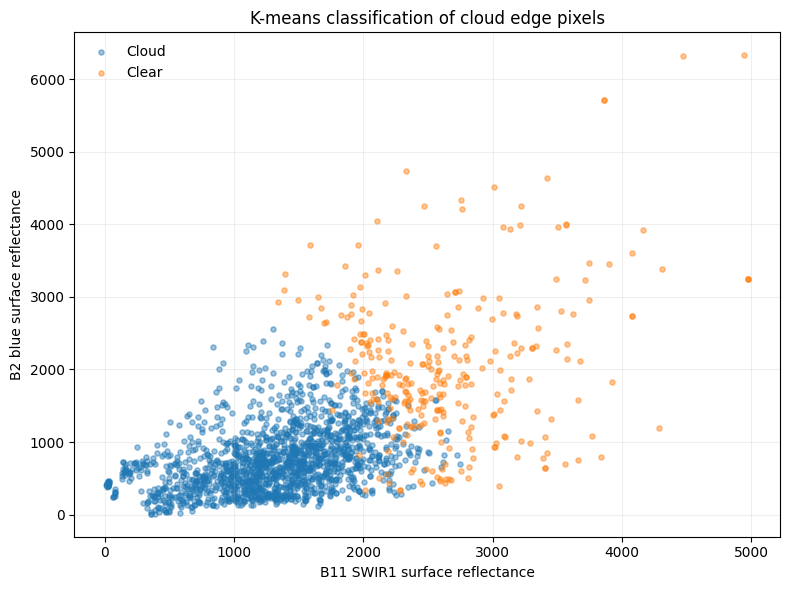

In [34]:
# Plot two of the selected bands to inspect the classified edge pixels.
counts = edge_df['predicted_class'].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(8, 6))

for label in ['Cloud', 'Clear']:
    subset = edge_df[edge_df['predicted_class'] == label]
    ax.scatter(subset['B11'], subset['B2'], label=label, alpha=0.45, s=14)

ax.set_xlabel('B11 SWIR1 surface reflectance')
ax.set_ylabel('B2 blue surface reflectance')
ax.set_title('K-means classification of cloud edge pixels')
ax.legend(frameon=False)
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

Finally, we will map this back onto earth engine via the following workflow:
1.  Export the classified edge pixels back to Earth Engine as a FeatureCollection
2. Rasterize the classified edge points into an image layer
3. Visualize refined cloud mask in Earth Engine (geemap):

Export to Earth Engine FC:

In [35]:
# Function to go the other way! This time from a dataframe to the feature collection
def df_to_ee_fc(df):
    features = []
    for _, row in df.iterrows():
        geom = ee.Geometry.Point([row['longitude'], row['latitude']])
        props = {k: float(row[k]) for k in ['B2', 'B3', 'B4', 'B8', 'probability']}
        props['predicted_class'] = row['predicted_class']
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

edge_fc = df_to_ee_fc(edge_df)

Rasterize into image layer:

In [36]:
# Map predicted class to numeric
def class_to_numeric(feature):
    cls = feature.get('predicted_class')
    return feature.set('cloud_refined', ee.Number(ee.Algorithms.If(ee.String(cls).equals('Cloud'), 1, 0)))

edge_fc_num = edge_fc.map(class_to_numeric)

# Rasterize: paint 'cloud_refined' on a blank image
refined_cloud_mask = edge_fc_num.reduceToImage(
    properties=['cloud_refined'],
    reducer=ee.Reducer.first())

# Optionally, you can combine this refined mask with your existing cloudmask for a final refined mask
final_mask = s2_sr_median.select('cloudmask').max(refined_cloud_mask).rename('cloudmask_refined')


Visualize it:

In [37]:
Map = geemap.Map(basemap='HYBRID')
Map.centerObject(AOI, 12)

# Show original cloudmask
Map.addLayer(s2_sr_median.select('cloudmask'), {'palette': ['white', 'red']}, 'Original cloudmask')

# Show refined cloudmask
Map.addLayer(final_mask.selfMask(), {'palette': ['blue']}, 'Refined cloudmask')

Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Hopefully, what you should now see above is a patch of downtown Auckland that has your s2cloudless cloudmask and a scatter of blue pixels (i.e. the sample from within the AOI) that k-means has decided is cloud.

Your answer to Q5 should see this scatter of 'new cloudy' pixels be better associated with the known clouds than if you leave it as the default bands that I have provided.





(6) Exercise: take all you have learned in this lab and carry out the following improvements:
1. Increase the K-means sampling to be more representative of the whole scene. This means; sample regions for cloud, clear and cloud edge that are not just over downtown Auckland but from across multiple landcover types.
2. Take the model that you have trained here using SciKitLearn and use it to classify edge pixels across a whole satellite image.

Present your results in **two** figures. The first should show the results of upgrades to pt.1, the second the results of pt.2.

(15 pts)

To get you started on item 2, this might be how you plan out your workflow given that you cannot upload a python ML model directly to Earth Engine:
- Extract cluster centres from Python k-means.
- Pass centres as constants into EE.
- Write a per-pixel classification function assigning nearest cluster centre.
- Apply this function to edge pixels or the whole image as needed.

### Answer to Question 6
The sampling was expanded from the small downtown Auckland region to five locations representing different land-cover types across the wider scene. These include dense urban land, forest, coast and water, pasture and suburban land. Cloud and clear samples from the different regions are combined and balanced before K-means is fitted. The fitted SciKitLearn cluster centres are then transferred to Earth Engine. Every cloud edge pixel across the wider satellite scene is assigned to the nearest cluster centre using Euclidean distance. Pixels assigned to the cloud cluster are added to the original cloud mask.

Cloud samples: 638
Clear samples: 2953
Edge samples: 703

Available training samples:
class
Clear    2953
Cloud     638
Name: count, dtype: int64

Balanced training samples:
class
Clear    638
Cloud    638
Name: count, dtype: int64

Cloud fraction in each cluster:
{0: np.float64(0.9275862068965517), 1: np.float64(0.3742393509127789)}

Cloud cluster: 0
Clear cluster: 1


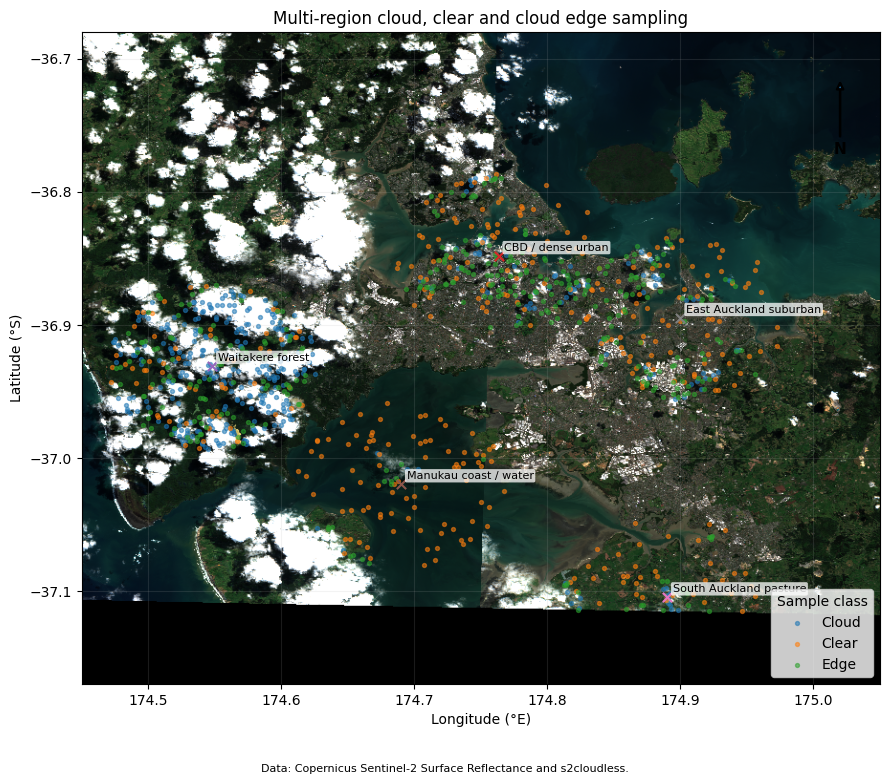


Saved: /content/lab3_outputs/Lab3_Q6a_multiregion_sampling.png


In [38]:
# QUESTION 6, PART 1
# Increase the sampling so cloud, clear and edge pixels are taken from
# multiple land-cover settings across the wider Auckland scene.

CLD_PRB_THRESH = 30
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 5

scene_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

# Keep the spectral values unmasked here because cloud spectra are needed
# for the K-means training samples.
scene_img = scene_col.map(add_cld_shdw_mask).mosaic()

SAMPLE_SITES = [
    ('CBD / dense urban', 174.7633, -36.8485),
    ('Waitakere forest', 174.5480, -36.9310),
    ('Manukau coast / water', 174.6900, -37.0200),
    ('South Auckland pasture', 174.8900, -37.1050),
    ('East Auckland suburban', 174.9000, -36.8950)
]

site_regions = [
    (name, ee.Geometry.Point([lon, lat]).buffer(7000))
    for name, lon, lat in SAMPLE_SITES
]

SAMPLE_BANDS = [
    'B2', 'B3', 'B4', 'B5', 'B6',
    'B8', 'B9', 'B11', 'B12',
    'probability'
]

def sample_region(img, region, site_name, n=700, edge_radius=20, seed=0):
    cloudmask = img.select('cloudmask')

    # Keep the cloud and clear samples away from the cloud boundary.
    cloud_interior = cloudmask.selfMask().focal_min(3)
    clear_interior = cloudmask.Not().selfMask().focal_min(10)

    # Cloud edge pixels are outside the current cloud mask but close to a detected cloud.
    cloud_edge = (
        cloudmask
        .focal_max(edge_radius)
        .And(cloudmask.Not())
        .selfMask()
    )

    stack = img.select(SAMPLE_BANDS)

    def take(mask, class_name, local_seed):
        return (
            stack
            .updateMask(mask)
            .sample(
                region=region,
                scale=20,
                numPixels=n,
                seed=local_seed,
                geometries=True
            )
            .map(
                lambda f: f.set({
                    'sample_class': class_name,
                    'site': site_name
                })
            )
        )

    return (
        take(cloud_interior, 'Cloud', seed),
        take(clear_interior, 'Clear', seed + 1),
        take(cloud_edge, 'Edge', seed + 2)
    )

# Collect samples from all five locations.
cloud_multi = ee.FeatureCollection([])
clear_multi = ee.FeatureCollection([])
edge_multi = ee.FeatureCollection([])

for i, (name, region) in enumerate(site_regions):
    cloud_fc, clear_fc, edge_fc_site = sample_region(
        scene_img,
        region,
        name,
        n=700,
        seed=100 * i
    )

    cloud_multi = cloud_multi.merge(cloud_fc)
    clear_multi = clear_multi.merge(clear_fc)
    edge_multi = edge_multi.merge(edge_fc_site)

# Convert the Earth Engine FeatureCollections to pandas DataFrames.
cloud_multi_df = fc_to_df(cloud_multi)
clear_multi_df = fc_to_df(clear_multi)
edge_multi_df = fc_to_df(edge_multi)

print('Cloud samples:', len(cloud_multi_df))
print('Clear samples:', len(clear_multi_df))
print('Edge samples:', len(edge_multi_df))

# Add class labels.
cloud_multi_df['class'] = 'Cloud'
clear_multi_df['class'] = 'Clear'

# Combine cloud and clear samples and remove missing values.
train_multi = pd.concat(
    [cloud_multi_df, clear_multi_df],
    ignore_index=True
)

train_multi = (
    train_multi
    .dropna(subset=features)
    .reset_index(drop=True)
)

class_counts = train_multi['class'].value_counts()

print()
print('Available training samples:')
print(class_counts)

if len(class_counts) < 2 or class_counts.min() == 0:
    raise RuntimeError(
        'Not enough cloud and clear samples were returned. '
        'Increase the sampling region size or use a different date range.'
    )

# Balance the training data so cloud and clear contribute equally.
min_n = int(class_counts.min())

train_multi_bal = (
    train_multi
    .groupby('class', group_keys=False)
    .sample(n=min_n, random_state=42)
    .reset_index(drop=True)
)

print()
print('Balanced training samples:')
print(train_multi_bal['class'].value_counts())

# Build the K-means input data.
X_multi = train_multi_bal[features].values
y_multi = (train_multi_bal['class'] == 'Cloud').astype(int).values

# Fit K-means using the same selected bands as above.
kmeans_multi = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=30
)
kmeans_multi.fit(X_multi)

# Determine which K-means cluster corresponds most strongly to cloud.
cluster_cloud_fraction = {}

for cluster in [0, 1]:
    in_cluster = kmeans_multi.labels_ == cluster

    if in_cluster.sum() > 0:
        cluster_cloud_fraction[cluster] = y_multi[in_cluster].mean()
    else:
        cluster_cloud_fraction[cluster] = 0

print()
print('Cloud fraction in each cluster:')
print(cluster_cloud_fraction)

cloud_cluster_multi = max(
    cluster_cloud_fraction,
    key=cluster_cloud_fraction.get
)

clear_cluster_multi = 1 - cloud_cluster_multi

print()
print('Cloud cluster:', cloud_cluster_multi)
print('Clear cluster:', clear_cluster_multi)

# ------------------------------------------------------------
# FIGURE 2
# Show where the improved samples were collected.
# ------------------------------------------------------------

# Earth Engine bounding box: [xmin, ymin, xmax, ymax]
plot_extent = [
    174.45,
    -37.17,
    175.05,
    -36.68
]

plot_region = ee.Geometry.Rectangle(
    plot_extent,
    proj='EPSG:4326',
    geodesic=False
)

# Matplotlib extent: [left, right, bottom, top]
mpl_extent = [
    plot_extent[0],
    plot_extent[2],
    plot_extent[1],
    plot_extent[3]
]

# Extract a true-colour image for the background.
rgb_np = geemap.ee_to_numpy(
    scene_img.select(['B4', 'B3', 'B2']),
    region=plot_region,
    scale=80
)

rgb_np = np.clip(
    rgb_np / 3000.0,
    0,
    1
)

fig, ax = plt.subplots(figsize=(9, 8))

ax.imshow(
    rgb_np,
    extent=mpl_extent,
    origin='upper'
)

plot_groups = [
    ('Cloud', cloud_multi_df),
    ('Clear', clear_multi_df),
    ('Edge', edge_multi_df)
]

for label, df in plot_groups:
    if len(df) > 0:
        sample_for_plot = df.sample(
            min(350, len(df)),
            random_state=42
        )

        ax.scatter(
            sample_for_plot['longitude'],
            sample_for_plot['latitude'],
            s=8,
            alpha=0.55,
            label=label
        )

# Mark the five sampling areas.
for name, lon, lat in SAMPLE_SITES:
    ax.scatter(
        lon,
        lat,
        s=45,
        marker='x'
    )

    ax.annotate(
        name,
        (lon, lat),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
        bbox=dict(
            boxstyle='round,pad=0.15',
            fc='white',
            alpha=0.75,
            ec='none'
        )
    )

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°S)')
ax.set_title('Multi-region cloud, clear and cloud edge sampling')
ax.legend(title='Sample class', loc='lower right')
ax.grid(alpha=0.15)

# North arrow.
ax.annotate(
    'N',
    xy=(0.95, 0.93),
    xytext=(0.95, 0.82),
    xycoords='axes fraction',
    ha='center',
    va='center',
    fontsize=11,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='-|>',
        lw=1.8
    )
)

fig.text(
    0.5,
    0.01,
    'Data: Copernicus Sentinel-2 Surface Reflectance and s2cloudless.',
    ha='center',
    fontsize=8
)

fig.tight_layout(rect=[0, 0.03, 1, 1])

q6a_path = OUTPUT_DIR / 'Lab3_Q6a_multiregion_sampling.png'

fig.savefig(
    q6a_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print()
print('Saved:', q6a_path)

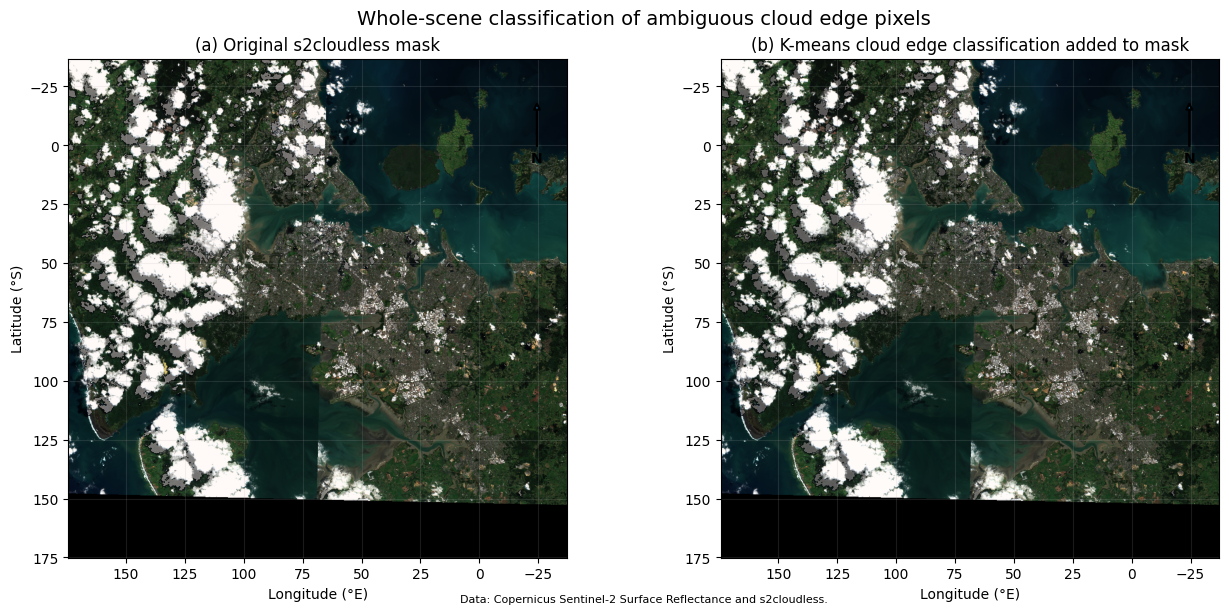

Original mask: 15.5% of displayed pixels.
Additional K-means edge pixels: 0.4% of displayed pixels.
Refined mask: 15.9% of displayed pixels.
Saved: /content/lab3_outputs/Lab3_Q6b_whole_scene_refinement.png


In [39]:
# QUESTION 6, PART 2
# Transfer the fitted SciKitLearn cluster centres to Earth Engine and classify
# cloud edge pixels across the wider satellite image.

centres = kmeans_multi.cluster_centers_

def squared_distance_to_centre(image, centre):
    centre_image = ee.Image.constant(
        [float(value) for value in centre]
    ).rename(features)

    return (
        image
        .select(features)
        .subtract(centre_image)
        .pow(2)
        .reduce(ee.Reducer.sum())
    )

distance_0 = squared_distance_to_centre(
    scene_img,
    centres[0]
).rename('distance_0')

distance_1 = squared_distance_to_centre(
    scene_img,
    centres[1]
).rename('distance_1')

# Cluster value is 0 when centre 0 is closest and 1 when centre 1 is closest.
cluster_image = distance_1.lt(distance_0).rename('cluster')

original_cloudmask = scene_img.select('cloudmask').gt(0)

# Classify the cloud edge zone across the displayed satellite scene.
whole_scene_edge = (
    original_cloudmask
    .focal_max(20)
    .And(original_cloudmask.Not())
)

new_cloud_edge = (
    cluster_image.eq(cloud_cluster_multi)
    .And(whole_scene_edge)
    .rename('new_cloud_edge')
)

refined_cloudmask_scene = (
    original_cloudmask
    .Or(new_cloud_edge)
    .rename('cloudmask_refined')
)

# Interactive check.
Map_q6 = geemap.Map(basemap='HYBRID')
Map_q6.centerObject(AOI, 9)

Map_q6.addLayer(
    scene_img,
    {
        'bands': ['B4', 'B3', 'B2'],
        'min': 0,
        'max': 3000,
        'gamma': 1.1
    },
    'Sentinel-2 true colour'
)

Map_q6.addLayer(
    original_cloudmask.selfMask(),
    {'palette': ['red']},
    'Original cloud mask'
)

Map_q6.addLayer(
    new_cloud_edge.selfMask(),
    {'palette': ['blue']},
    'Cloud edge pixels added by K-means'
)

Map_q6.addLayer(
    refined_cloudmask_scene.selfMask(),
    {'palette': ['magenta']},
    'Final refined cloud mask',
    False
)

Map_q6

# Figure 3: whole-scene comparison.
q6_stack = ee.Image.cat([
    scene_img.select(['B4', 'B3', 'B2']).rename(['R', 'G', 'B']),
    original_cloudmask.rename('original'),
    new_cloud_edge.rename('added'),
    refined_cloudmask_scene.rename('refined')
])

q6_np = geemap.ee_to_numpy(
    q6_stack,
    region=plot_region,
    scale=60
)

q6_rgb = np.clip(
    q6_np[..., :3] / 3000.0,
    0,
    1
)

q6_original = q6_np[..., 3] > 0.5
q6_added = q6_np[..., 4] > 0.5
q6_refined = q6_np[..., 5] > 0.5

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 6),
    constrained_layout=True
)

axes[0].imshow(
    q6_rgb,
    extent=mpl_extent,
    origin='upper'
)

axes[0].imshow(
    np.ma.masked_where(~q6_original, q6_original),
    extent=mpl_extent,
    origin='upper',
    alpha=0.45,
    cmap='Reds'
)

axes[0].set_title('(a) Original s2cloudless mask')

axes[1].imshow(
    q6_rgb,
    extent=mpl_extent,
    origin='upper'
)

axes[1].imshow(
    np.ma.masked_where(~q6_original, q6_original),
    extent=mpl_extent,
    origin='upper',
    alpha=0.35,
    cmap='Reds'
)

axes[1].imshow(
    np.ma.masked_where(~q6_added, q6_added),
    extent=mpl_extent,
    origin='upper',
    alpha=0.75,
    cmap='Blues'
)

axes[1].set_title('(b) K-means cloud edge classification added to mask')

for ax in axes:
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°S)')
    ax.grid(alpha=0.15)

    ax.annotate(
        'N',
        xy=(0.94, 0.92),
        xytext=(0.94, 0.80),
        xycoords='axes fraction',
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='-|>',
            lw=1.6
        )
    )

fig.suptitle(
    'Whole-scene classification of ambiguous cloud edge pixels',
    fontsize=14
)

fig.text(
    0.5,
    0.005,
    'Data: Copernicus Sentinel-2 Surface Reflectance and s2cloudless.',
    ha='center',
    fontsize=8
)

q6b_path = OUTPUT_DIR / 'Lab3_Q6b_whole_scene_refinement.png'

fig.savefig(
    q6b_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

q6_original_fraction = float(q6_original.mean() * 100)
q6_added_fraction = float(q6_added.mean() * 100)
q6_refined_fraction = float(q6_refined.mean() * 100)

print(f'Original mask: {q6_original_fraction:.1f}% of displayed pixels.')
print(f'Additional K-means edge pixels: {q6_added_fraction:.1f}% of displayed pixels.')
print(f'Refined mask: {q6_refined_fraction:.1f}% of displayed pixels.')
print('Saved:', q6b_path)

### Question 6 figure captions
Figure 2 shows the expanded sampling used for the K-means model. The training data are no longer restricted to central Auckland and include cloud, clear and cloud edge pixels from urban, forest, coastal, pasture and suburban environments.

Figure 3 shows the model applied to cloud edge pixels across the wider Sentinel-2 scene. The original s2cloudless detections are retained and the K-means model adds edge pixels whose B2, B8, B11 and B12 values are closest to the cloud cluster centre.